# Empirical Distributions and Financial Risk

Observed returns provide a finite realization of an unknown population. Unlike the preceding simulations, the true distribution and its risk measures are unavailable. I therefore compare several descriptions of the same observations rather than identify a known DGP.

The main examples are the US S&P 500 and Germany's DAX price index over 2017–2025. I first analyze each market in its local currency, then construct a common-currency joint example and a fixed-weight portfolio.

Distribution fitting and sampling interpretations use an iid working assumption. Actual returns can be dependent and their distributions can change across the window. This pooled analysis does not establish independence or a stable population, which the later time-series notebooks address.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from scipy.integrate import quad
from finstats.nonparametric import empirical_cdf, empirical_quantile, qq_data
from finstats.risk import (
    historical_var, historical_es, gaussian_var, gaussian_es, student_t_var, student_t_es,
)
from finstats.multivariate import covariance_matrix, correlation, linear_combination_mean, linear_combination_variance
from finance_statistical_methods.returns.returns import simple_returns, log_returns
from finance_statistical_methods.distributions.univariate import normal, student_t, laplace, skew_normal

## 1. Markets, data, and return conventions

I use unadjusted closing levels of the S&P 500 price index in USD and the DAX price index in EUR. Both exclude reinvested dividends. The DAX series here is the price version, not the commonly quoted performance index. This keeps their dividend treatment comparable. Index levels describe benchmarks rather than the full returns of investable funds.

The fixed window is January 2017 through December 2025. The local CSV snapshots and their sources, currencies, missing observations, and checksums are documented in `data/README.md` and `data/manifest.json`. The notebooks require no network access.

For price observations,
$$R_t=P_t/P_{t-1}-1,\qquad r_t=\log(P_t/P_{t-1}).$$
I use simple returns in percentage points throughout this notebook. This makes the later fixed-weight portfolio relation exact. The original course's log-return dataset remains available separately. No prices or returns are winsorized, interpolated, or forward-filled.

For illustration, the first figure compares rebased closing levels in each market's own currency. It is not a common-currency investor performance comparison.

,series,observed prices,first date,last date
0,S&P 500,2262,2017-01-03,2025-12-31
1,DAX price,2280,2017-01-03,2025-12-30
2,EURUSD,2341,2017-01-02,2025-12-31


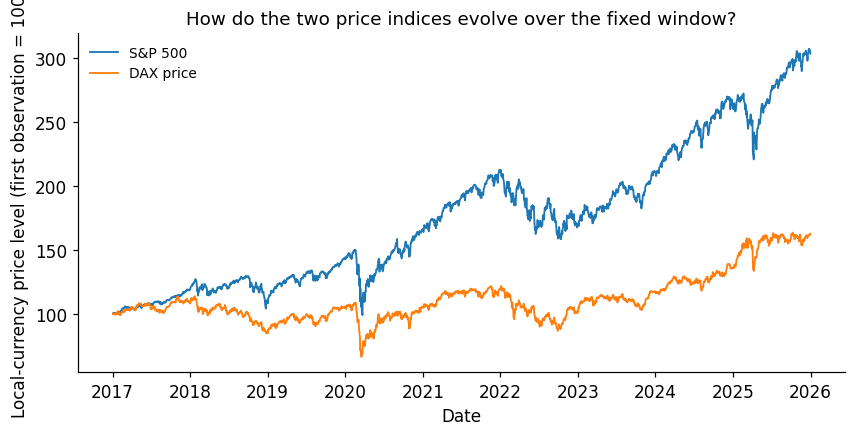

In [2]:
file_names = {
    "S&P 500": "sp500_prices_2017_2025.csv",
    "DAX price": "dax_price_prices_2017_2025.csv",
    "EURUSD": "eurusd_2017_2025.csv",
}
price_series = {}
for name, file_name in file_names.items():
    frame = pd.read_csv(repository / "data" / file_name, parse_dates=["Date"]).set_index("Date")
    assert frame.index.is_unique and frame.index.is_monotonic_increasing
    assert np.isfinite(frame["Close"]).all() and (frame["Close"]>0).all()
    price_series[name] = frame["Close"]
display(pd.DataFrame([{"series": name, "observed prices": len(values), "first date": values.index.min().date(),
                      "last date": values.index.max().date()} for name, values in price_series.items()]))
fig, ax = plt.subplots(figsize=(9, 4))
for name in ("S&P 500", "DAX price"):
    values = price_series[name]
    ax.plot(values.index, values/values.iloc[0]*100, linewidth=1.2, label=name)
ax.set(xlabel="Date", ylabel="Local-currency price level (first observation = 100)",
       title="How do the two price indices evolve over the fixed window?")
ax.legend(fontsize=9)
plt.show()
market_returns = {
    name: pd.Series(100*simple_returns(price_series[name].to_numpy()), index=price_series[name].index[1:])
    for name in ("S&P 500", "DAX price")
}

## 2. Return observations and sample summaries

The sample mean, standard deviation, skewness, and raw kurtosis summarize location, dispersion, asymmetry, and extreme centered deviations. They are estimates or descriptions of this window, not known population moments.

For illustration, I show the local-market return histories and summarize them using the conventions from Notebook 01. The observations use each market's own trading calendar. A daily trading return can span a weekend or holiday.

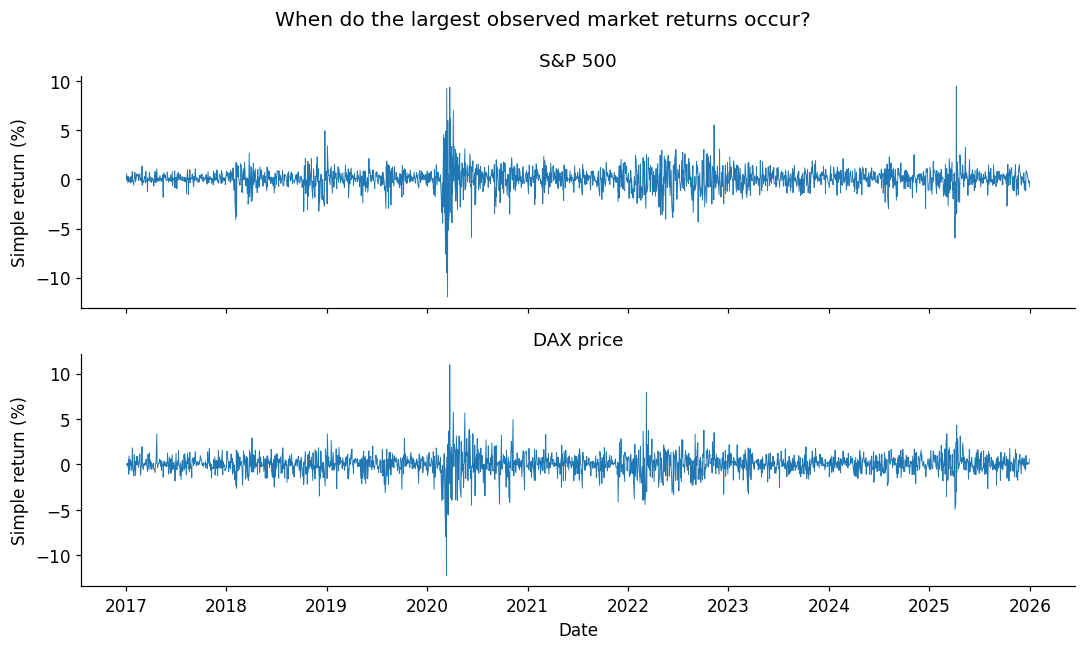

,n,mean (%),SD (%),skewness,raw kurtosis,minimum (%),maximum (%)
market,,,,,,,
S&P 500,2261,0.056,1.1725,-0.3752,18.5487,-11.9841,9.5154
DAX price,2279,0.028,1.1530,-0.4067,15.9871,-12.2397,10.9759


In [3]:
summary_rows = []
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, (name, values) in zip(axes, market_returns.items()):
    ax.plot(values.index, values, linewidth=.6)
    ax.set(ylabel="Simple return (%)", title=name)
    summary_rows.append({"market": name, "n": len(values), "mean (%)": sample_mean(values),
                         "SD (%)": sample_standard_deviation(values), "skewness": sample_skewness(values),
                         "raw kurtosis": sample_kurtosis(values), "minimum (%)": values.min(), "maximum (%)": values.max()})
axes[-1].set_xlabel("Date")
fig.suptitle("When do the largest observed market returns occur?")
fig.tight_layout()
plt.show()
display(pd.DataFrame(summary_rows).set_index("market").round(4))

The histories locate large movements that a pooled distribution treats as observations from one working population. Sample skewness and kurtosis describe this realization. They do not establish the existence of the corresponding population moments.

## 3. Non-parametric descriptions

The ECDF counts cumulative observations, while KDE gives a smoothed density. Neither imposes one of the parametric families from Notebook 01. Their definitions and sampling illustrations are in Notebook 04.

For illustration, I compare both markets over the central return region, using the default Gaussian KDE bandwidth. The ECDF panel also shows a Gaussian benchmark with the same sample mean and standard deviation. That benchmark is a shape reference rather than a fitted winner.

S&P 500: 8 returns outside ±6%, retained in all calculations
DAX price: 4 returns outside ±6%, retained in all calculations


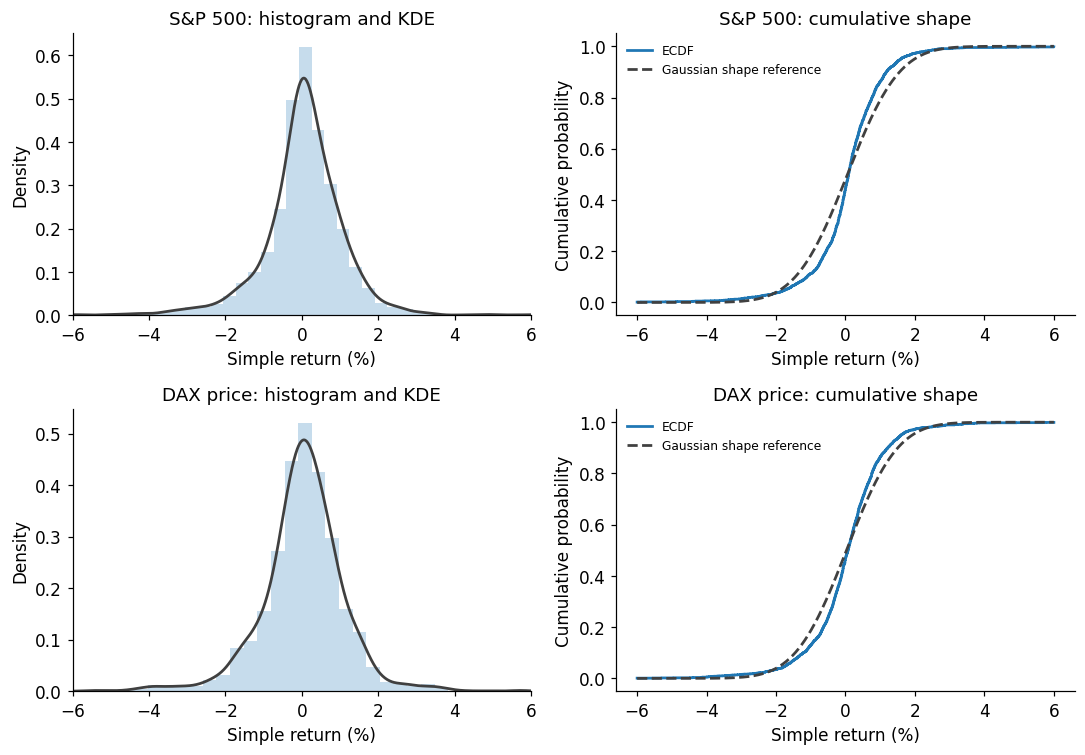

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, (name, series) in enumerate(market_returns.items()):
    values = series.to_numpy()
    display_grid = np.linspace(-6, 6, 801)
    kde = stats.gaussian_kde(values)
    axes[row,0].hist(values, bins=65, density=True, alpha=.25)
    axes[row,0].plot(display_grid, kde(display_grid), color="0.25", label="KDE")
    axes[row,0].set(xlabel="Simple return (%)", ylabel="Density", title=f"{name}: histogram and KDE", xlim=(-6, 6))
    axes[row,1].step(display_grid, empirical_cdf(values)(display_grid), where="post", label="ECDF")
    axes[row,1].plot(display_grid, stats.norm.cdf(display_grid, loc=sample_mean(values),
                                               scale=sample_standard_deviation(values)), "--", color="0.25", label="Gaussian shape reference")
    axes[row,1].set(xlabel="Simple return (%)", ylabel="Cumulative probability", title=f"{name}: cumulative shape")
    axes[row,1].legend(fontsize=8)
    print(f"{name}: {np.count_nonzero(abs(values)>6)} returns outside ±6%, retained in all calculations")
fig.tight_layout()
plt.show()

## 4. Parametric fitting and model comparison

I fit Gaussian, Student-t, Laplace, and skew-normal distributions by maximizing the iid log-likelihood from Notebook 03. Their parameters and densities were introduced in Notebook 01:

| Family | Parameters | Mean and variance |
|---|---|---|
| Gaussian | $\mu,\sigma>0$ | $\mu,\sigma^2$ |
| Student-t | $\mu,\lambda>0,\nu>0$ | $\mu$ for $\nu>1$, $\lambda^2\nu/(\nu-2)$ for $\nu>2$ |
| Laplace | $\mu,\lambda>0$ | $\mu,2\lambda^2$ |
| Skew-normal | $\mu,\lambda>0,\alpha$ | $\mu+\lambda\delta\sqrt{2/\pi},\lambda^2(1-2\delta^2/\pi)$, with $\delta=\alpha/\sqrt{1+\alpha^2}$ |

Location and scale therefore need not equal mean and standard deviation. Skew-normal shape captures asymmetry but does not give Student-t-type tails.

For each market, all candidates use the same observations in the same units. I report
$$AIC=-2\ell(\hat\theta)+2k,\qquad BIC=-2\ell(\hat\theta)+k\log n.$$
Lower values indicate a preferred candidate under that criterion. These are relative comparisons rather than tests that a distribution is true. Numerical likelihood fitting can depend on its optimization, which was illustrated in Notebook 03.

In [5]:
fit_modules = {"Gaussian": normal, "Student-t": student_t, "Laplace": laplace, "Skew-normal": skew_normal}
market_fits, fitted_distributions, fit_rows = {}, {}, []
for market, series in market_returns.items():
    market_fits[market] = {name: module.fit(series.to_numpy()) for name, module in fit_modules.items()}
    fitted_distributions[market] = {}
    for name, result in market_fits[market].items():
        parameters = result["params"]
        scale = parameters.get("sigma", parameters.get("scale"))
        if name == "Gaussian":
            distribution = stats.norm(loc=parameters["mu"], scale=scale)
        elif name == "Student-t":
            distribution = stats.t(parameters["df"], loc=parameters["mu"], scale=scale)
        elif name == "Laplace":
            distribution = stats.laplace(loc=parameters["mu"], scale=scale)
        else:
            distribution = stats.skewnorm(parameters["alpha"], loc=parameters["mu"], scale=scale)
        fitted_distributions[market][name] = distribution
        fit_rows.append({"market": market, "family": name, "location": parameters["mu"], "scale": scale,
                         "df": parameters.get("df", np.nan), "shape": parameters.get("alpha", np.nan),
                         "implied mean": distribution.mean(), "implied SD": distribution.std(),
                         "log-likelihood": result["log_likelihood"], "k": len(parameters),
                         "AIC": result["aic"], "BIC": result["bic"]})
fit_table = pd.DataFrame(fit_rows).set_index(["market", "family"])
display(fit_table.round(4))
preferred_family = {market: min(results, key=lambda name: results[name]["aic"])
                    for market, results in market_fits.items()}
print("Lowest AIC within each candidate set:", preferred_family)

location   scale      df   shape  implied mean  \
market    family                                                        
S&P 500   Gaussian       0.0560  1.1723     NaN     NaN        0.0560   
          Student-t      0.0992  0.6408  2.5542     NaN        0.0992   
          Laplace        0.0820  0.7480     NaN     NaN        0.0820   
          Skew-normal    0.8327  1.4062     NaN -0.9846        0.0454   
DAX price Gaussian       0.0280  1.1527     NaN     NaN        0.0280   
          Student-t      0.0672  0.7215  3.1198     NaN        0.0672   
          Laplace        0.0665  0.7778     NaN     NaN        0.0665   
          Skew-normal    0.8158  1.3962     NaN -1.0236        0.0190   

                       implied SD  log-likelihood  k        AIC        BIC  
market    family                                                            
S&P 500   Gaussian         1.1723      -3567.5628  2  7139.1255  7150.5727  
          Student-t        1.3756      -3149.9163  3  6305.8326  6323.0032  
          Laplace          1.0578      -3171.5894  2  6347.1788  6358.6259  
          Skew-normal      1.1652      -3550.5364  3  7107.0727  7124.2434  
DAX price Gaussian         1.1527      -3557.6205  2  7119.2410  7130.7040  
          Student-t        1.2043      -3265.5311  3  6537.0623  6554.2568  
          Laplace          1.1000      -3285.9632  2  6575.9265  6587.3894  
          Skew-normal      1.1464      -3540.8240  3  7087.6480  7104.8425

Lowest AIC within each candidate set: {'S&P 500': 'Student-t', 'DAX price': 'Student-t'}


Student-t has the lowest AIC and BIC among these candidates for both markets. The fitted degrees of freedom are about 2.55 for S&P 500 and 3.12 for DAX. Both fits imply finite variance but no finite fourth moment. The computable sample kurtosis does not resolve whether a population fourth moment exists.

The Gaussian and skew-normal fits have similar implied dispersion, while the Student-t model changes tail decay. These are model implications for this window rather than established population properties.

### Center and negative tail

For illustration, I plot the fitted densities against the KDE in the central region and the empirical exceedance probability for large losses. The loss tail is the negative return tail, $P(L>l)=P(R<-l)$. A log probability scale makes rare outcomes visible. Zero empirical exceedance frequencies are not plotted on that scale, but are retained in the ECDF.

The curves describe fitted marginal distributions over the whole window. They are not conditional forecasts or out-of-sample validation.

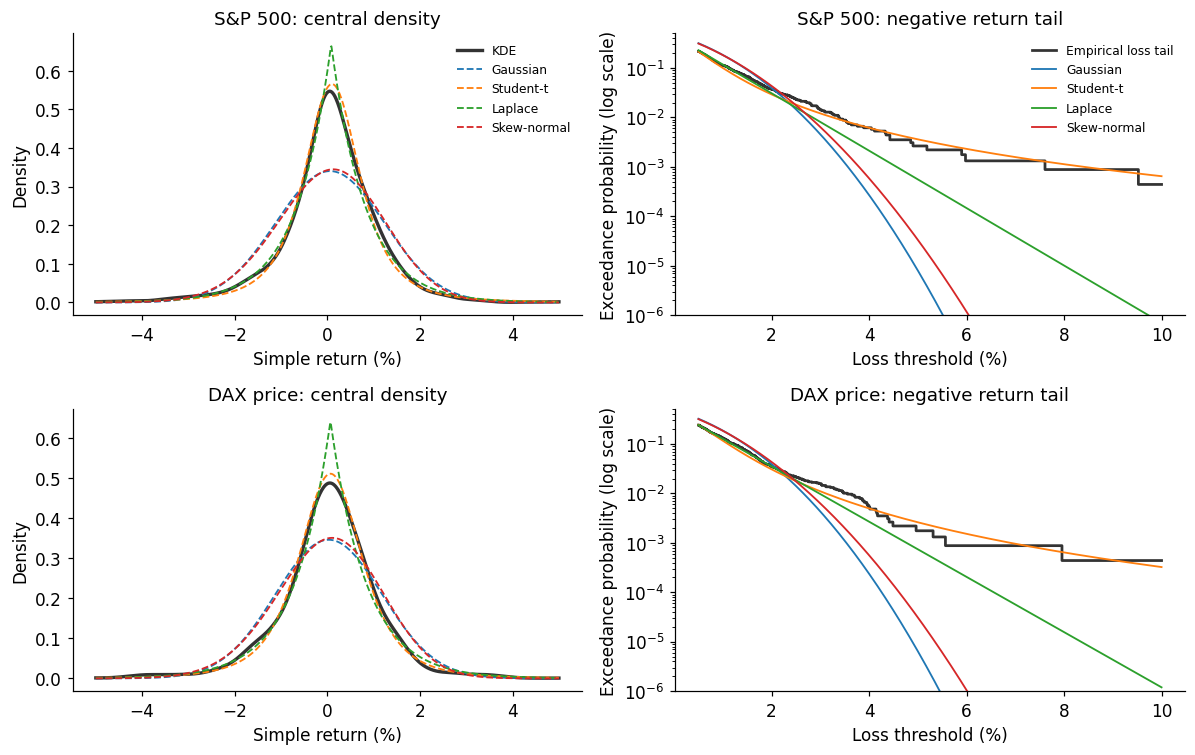

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, (market, series) in enumerate(market_returns.items()):
    values = series.to_numpy()
    central_grid = np.linspace(-5, 5, 801)
    tail_grid = np.linspace(.5, 10, 601)
    axes[row,0].plot(central_grid, stats.gaussian_kde(values)(central_grid), color="0.2", linewidth=2.2, label="KDE")
    observed_tail = 1-empirical_cdf(-values)(tail_grid)
    positive = observed_tail>0
    axes[row,1].step(tail_grid[positive], observed_tail[positive], where="post", color="0.2", label="Empirical loss tail")
    for name, distribution in fitted_distributions[market].items():
        axes[row,0].plot(central_grid, distribution.pdf(central_grid), "--", linewidth=1.2, label=name)
        axes[row,1].semilogy(tail_grid, distribution.cdf(-tail_grid), linewidth=1.2, label=name)
    axes[row,0].set(xlabel="Simple return (%)", ylabel="Density", title=f"{market}: central density")
    axes[row,1].set(xlabel="Loss threshold (%)", ylabel="Exceedance probability (log scale)",
                    title=f"{market}: negative return tail", ylim=(1e-6, .5))
axes[0,0].legend(fontsize=8)
axes[0,1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The fitted Student-t density is closer to the central KDE and permits substantially larger extreme-loss probabilities than the Gaussian. Its tail curve is nevertheless smooth, while the empirical curve is supported by a few large observations. Agreement over part of the plotted range cannot validate probabilities beyond the available data.

### Quantile comparisons

For illustration, I compare each sample with its fitted Gaussian and lowest-AIC family. Reference quantiles and observations have the same percentage-point units, so the identity line is the fitted comparison. Tail deviations remain visible even when a family has the best overall criterion value.

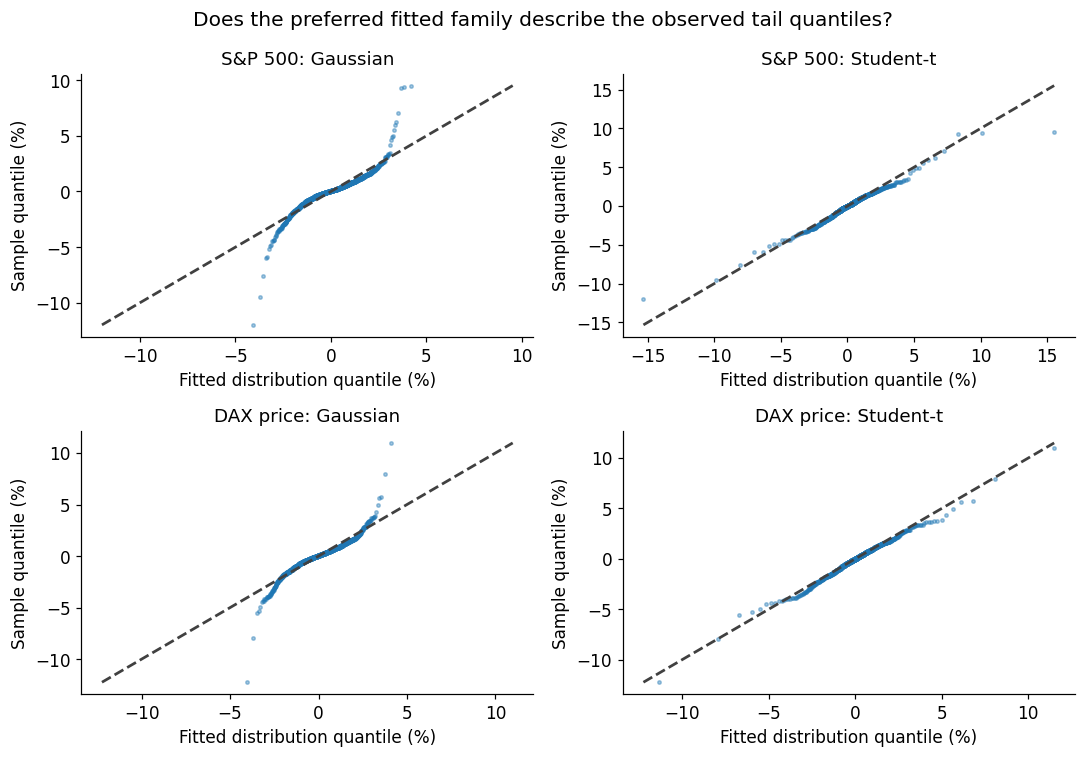

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, (market, series) in enumerate(market_returns.items()):
    for ax, name in zip(axes[row], ("Gaussian", preferred_family[market])):
        reference, observed = qq_data(series.to_numpy(), fitted_distributions[market][name])
        ax.scatter(reference, observed, s=5, alpha=.4)
        limits = [min(reference.min(), observed.min()), max(reference.max(), observed.max())]
        ax.plot(limits, limits, "--", color="0.25")
        ax.set(xlabel="Fitted distribution quantile (%)", ylabel="Sample quantile (%)", title=f"{market}: {name}")
fig.suptitle("Does the preferred fitted family describe the observed tail quantiles?")
fig.tight_layout()
plt.show()

## 5. Historical and parametric loss risk

Define losses as minus the percentage simple returns. Notebook 05 derived VaR and ES. Here the historical estimates use inverse-ECDF quantiles and strict exceedances, while the parametric estimates use fitted loss distributions.

Negating a symmetric return family changes the location sign and leaves its scale unchanged. Negating a skew-normal also reverses its shape parameter. This distinction matters for upper-tail losses.

For illustration, I compare 5% and 1% risk for each market. Gaussian and Student-t estimates use the reusable formulas. Laplace and skew-normal ES use the defining upper-tail integral. The table includes the historical tail count to show how many observations support its estimate. All values refer to each market's own trading intervals, in its local currency.

VaR (%)  ES (%)  strict tail count
market    alpha method                                         
S&P 500   0.05  Historical    1.7260  2.8622              113.0
                Gaussian      1.8722  2.3621                NaN
                Student-t     1.5223  2.7803                NaN
                Laplace       1.6402  2.3882                NaN
                Skew-normal   1.9152  2.4509                NaN
          0.01  Historical    3.3688  5.0099               22.0
                Gaussian      2.6711  3.0684                NaN
                Student-t     3.2580  5.5284                NaN
                Laplace       2.8440  3.5920                NaN
                Skew-normal   2.7882  3.2334                NaN
DAX price 0.05  Historical    1.7221  2.7780              113.0
                Gaussian      1.8680  2.3497                NaN
                Student-t     1.6045  2.6431                NaN
                Laplace       1.7244  2.5022                NaN
                Skew-normal   1.9139  2.4451                NaN
          0.01  Historical    3.5435  4.7277               22.0
                Gaussian      2.6535  3.0442                NaN
                Student-t     3.1105  4.7515                NaN
                Laplace       2.9762  3.7540                NaN
                Skew-normal   2.7795  3.2214                NaN

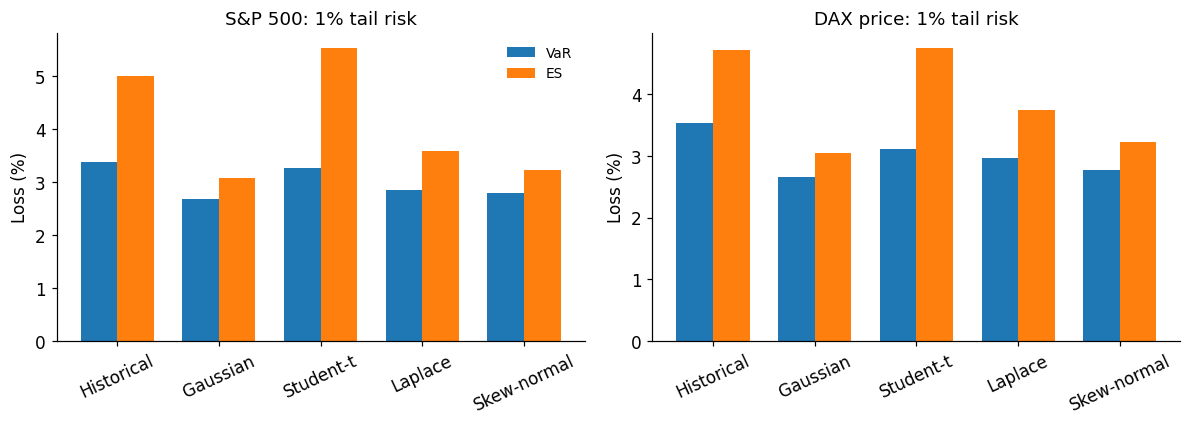

In [8]:
risk_rows = []
for market, series in market_returns.items():
    losses = -series.to_numpy()
    for alpha in (.05, .01):
        threshold = historical_var(losses, alpha)
        risk_rows.append({"market": market, "alpha": alpha, "method": "Historical", "VaR (%)": threshold,
                          "ES (%)": historical_es(losses, alpha), "strict tail count": np.count_nonzero(losses>threshold)})
        for name, fit in market_fits[market].items():
            p = fit["params"]
            if name == "Gaussian":
                var = gaussian_var(-p["mu"], p["sigma"], alpha)
                es = gaussian_es(-p["mu"], p["sigma"], alpha)
            elif name == "Student-t":
                var = student_t_var(-p["mu"], p["scale"], p["df"], alpha)
                es = student_t_es(-p["mu"], p["scale"], p["df"], alpha) if p["df"]>1 else np.inf
            else:
                loss_distribution = (stats.laplace(loc=-p["mu"], scale=p["scale"]) if name == "Laplace"
                                     else stats.skewnorm(-p["alpha"], loc=-p["mu"], scale=p["scale"]))
                var = loss_distribution.isf(alpha)
                es = quad(lambda l: l*loss_distribution.pdf(l), var, np.inf)[0]/alpha
            risk_rows.append({"market": market, "alpha": alpha, "method": name, "VaR (%)": var,
                              "ES (%)": es, "strict tail count": np.nan})
risk_table = pd.DataFrame(risk_rows)
display(risk_table.set_index(["market", "alpha", "method"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, market in zip(axes, market_returns):
    values = risk_table[(risk_table.market==market)&(risk_table.alpha==.01)]
    positions = np.arange(len(values))
    ax.bar(positions-.18, values["VaR (%)"], width=.36, label="VaR")
    ax.bar(positions+.18, values["ES (%)"], width=.36, label="ES")
    ax.set(xticks=positions, xticklabels=values.method, ylabel="Loss (%)", title=f"{market}: 1% tail risk")
    ax.tick_params(axis="x", labelrotation=25)
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

AIC and BIC evaluate the full fitted likelihood, rather than the accuracy of a particular tail risk measure. Historical and parametric risk can therefore disagree even when their central distributions are similar. The preferred family remains an assumption, and an in-sample tail comparison does not validate a future risk forecast.

At the 1% level, S&P 500 historical VaR is about 3.37% and ES 5.01%, compared with Gaussian estimates of 2.67% and 3.07%. For DAX, the corresponding historical values are about 3.54% and 4.73%, compared with 2.65% and 3.04% under the Gaussian fit. Each historical ES uses 22 strict exceedances.

Student-t estimates are more consistent with these observed tail magnitudes, particularly DAX ES. This is an in-sample comparison with historical estimates, not an accuracy comparison against known population risk.

## 6. Aligning markets and currency

Joint returns require a common observation interval. I first intersect the observed US, German, and FX price dates, then calculate returns between successive shared dates. Joining already-calculated daily returns could combine different starting dates around holidays. No missing closing level is filled.

Let $Q_t$ be USD per EUR. The German price level in USD is
$$P^{US}_{D,t}=P^{EUR}_{D,t}Q_t,$$
so its simple USD return satisfies
$$1+R^{US}_{D,t}=(1+R^{EUR}_{D,t})(1+R_{Q,t}).$$
This includes currency exposure. The local-currency analysis above excluded it.

The closing observations are date-aligned, not simultaneous. German and US markets close at different times, and the daily FX quote has its own timestamp convention. The joint example is therefore a marked-close benchmark approximation. Consecutive common dates can span several calendar days, so its horizon is a common-date interval rather than an identical 24-hour period.

In [9]:
price_panel = pd.concat(price_series, axis=1)
aligned_prices = price_panel.dropna()
assert len(aligned_prices)>1000 and aligned_prices.index.is_unique
usd_levels = pd.DataFrame({"S&P 500": aligned_prices["S&P 500"],
                           "DAX (USD)": aligned_prices["DAX price"]*aligned_prices["EURUSD"]})
joint_returns = pd.DataFrame({name: 100*simple_returns(usd_levels[name].to_numpy()) for name in usd_levels},
                             index=usd_levels.index[1:])
days_between = np.diff(aligned_prices.index.to_numpy()).astype("timedelta64[D]").astype(int)
print(f"Shared price dates: {len(aligned_prices)}, paired return intervals: {len(joint_returns)}")
print(f"Shared window: {aligned_prices.index.min().date()} to {aligned_prices.index.max().date()}")
print(f"Intervals spanning more than one calendar day: {np.count_nonzero(days_between>1)}")
print("Missing prices by series on union of dates:")
print(price_panel.isna().sum())
# Verify currency compounding on the common intervals.
dax_local = simple_returns(aligned_prices["DAX price"].to_numpy())
fx_returns = simple_returns(aligned_prices["EURUSD"].to_numpy())
np.testing.assert_allclose(joint_returns["DAX (USD)"]/100, (1+dax_local)*(1+fx_returns)-1, atol=1e-12)

Shared price dates: 2217, paired return intervals: 2216
Shared window: 2017-01-03 to 2025-12-30
Intervals spanning more than one calendar day: 502
Missing prices by series on union of dates:
S&P 500      83
DAX price    65
EURUSD        4
dtype: int64


## 7. Joint returns and dependence

The sample mean vector and covariance matrix are
$$\bar{\mathbf r}=\frac1n\sum_i\mathbf r_i,\qquad
\hat\Sigma=\frac1{n-1}\sum_i(\mathbf r_i-\bar{\mathbf r})(\mathbf r_i-\bar{\mathbf r})^\top.$$
They summarize the paired sample rather than known population dependence. Notebook 02 showed how uncertain those inputs can be and why zero correlation does not establish independence.

For illustration, I plot the date-aligned USD return pairs with a fitted bivariate Gaussian reference. The contours describe a model determined by the estimated first two moments. They need not account for joint extreme outcomes.

Sample mean vector (%): [0.0573 0.0353]
Sample covariance matrix (%²):
 [[1.3798 0.7656]
 [0.7656 1.5847]]
Sample correlation: 0.5177


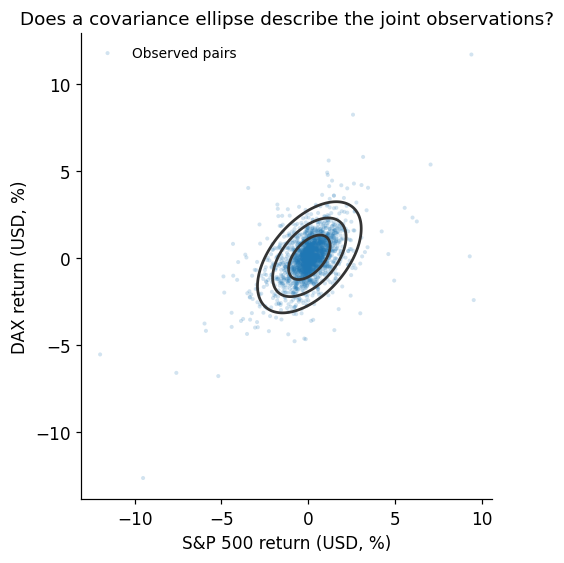

In [10]:
joint_values = joint_returns.to_numpy()
joint_mean = np.array([sample_mean(column) for column in joint_values.T])
joint_covariance = covariance_matrix(joint_values)
joint_correlation = correlation(joint_values[:,0], joint_values[:,1])
print("Sample mean vector (%):", np.round(joint_mean, 4))
print("Sample covariance matrix (%²):\n", np.round(joint_covariance, 4))
print(f"Sample correlation: {joint_correlation:.4f}")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(joint_values[:,0], joint_values[:,1], s=7, alpha=.2, edgecolors="none", label="Observed pairs")
axis_grid = np.linspace(-8, 8, 201)
mx, my = np.meshgrid(axis_grid, axis_grid)
reference_density = stats.multivariate_normal.pdf(np.stack((mx, my), axis=-1), mean=joint_mean, cov=joint_covariance)
ax.contour(mx, my, reference_density, levels=[.005, .025, .075], colors="0.2")
ax.set(xlabel="S&P 500 return (USD, %)", ylabel="DAX return (USD, %)", title="Does a covariance ellipse describe the joint observations?")
ax.set_aspect("equal", adjustable="box")
ax.legend(fontsize=9)
plt.show()

The estimated common-interval USD correlation is about 0.52. The markets move together on average, but their observed pairs include joint extremes that the first two moments do not fully describe. Currency conversion and closing-time differences are part of this estimate, which should not be interpreted as pure synchronous local-market dependence.

## 8. A fixed-weight portfolio

I use equal weights, chosen before inspecting the return estimates. At the start of each common interval, half the benchmark exposure is assigned to each market in USD. This is a rebalanced price-only benchmark, excluding dividends, fees, trading costs, and financing. It is not an optimized allocation or a buy-and-hold strategy with constant shares.

The simple portfolio return is
$$R_p=w^\top\mathbf R,\qquad E[R_p]=w^\top\mu,\qquad
\operatorname{Var}(R_p)=w^\top\Sigma w.$$
For the sample, the same relation gives $\bar r_p=w^\top\bar{\mathbf r}$ and $s_p^2=w^\top\hat\Sigma w$. A multivariate Gaussian assumption would also imply a Gaussian portfolio distribution. Outside that family, the moment formulas alone do not specify its tails.

For illustration, I verify the realized moment identities, then compare historical portfolio risk with Gaussian risk implied by the fitted joint moments. I also show each component on these same intervals so their risk estimates are directly comparable.

Portfolio sample mean: 0.0463%, SD: 1.0602%


VaR (%)  ES (%)  tail count
series          alpha method                                             
S&P 500         0.05  Historical               1.7260  2.8702       110.0
                0.01  Historical               3.3688  5.0099        22.0
DAX (USD)       0.05  Historical               1.9918  2.9659       110.0
                0.01  Historical               3.5125  4.7470        22.0
50/50 portfolio 0.05  Historical               1.5746  2.5501       110.0
                0.01  Historical               2.7987  4.4230        22.0
                0.05  Joint Gaussian moments   1.6975  2.1405         NaN
                0.01  Joint Gaussian moments   2.4200  2.7792         NaN

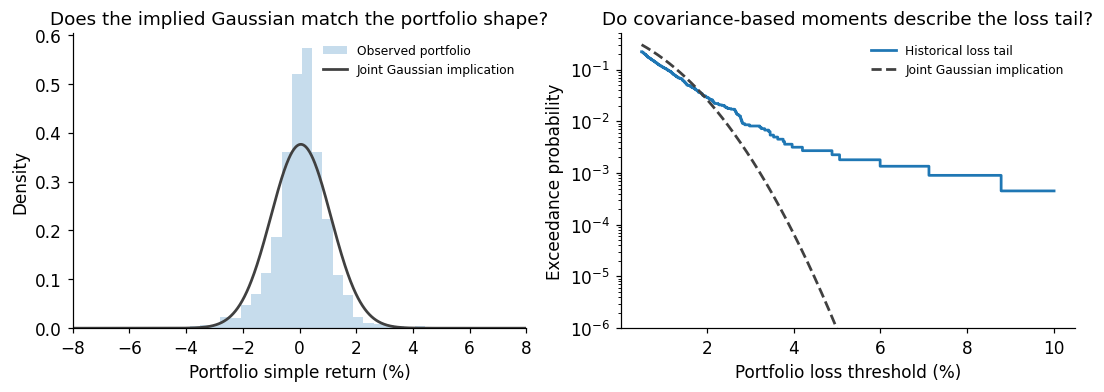

In [11]:
weights = np.array([.5, .5])
portfolio_returns = joint_values @ weights
portfolio_mean = linear_combination_mean(weights, joint_mean)
portfolio_variance = linear_combination_variance(weights, joint_covariance)
np.testing.assert_allclose(portfolio_mean, sample_mean(portfolio_returns))
np.testing.assert_allclose(portfolio_variance, sample_variance(portfolio_returns))
print(f"Portfolio sample mean: {portfolio_mean:.4f}%, SD: {np.sqrt(portfolio_variance):.4f}%")
portfolio_rows = []
for name, values in [("S&P 500", joint_values[:,0]), ("DAX (USD)", joint_values[:,1]), ("50/50 portfolio", portfolio_returns)]:
    losses = -values
    for alpha in (.05, .01):
        threshold = historical_var(losses, alpha)
        portfolio_rows.append({"series": name, "alpha": alpha, "method": "Historical", "VaR (%)": threshold,
                               "ES (%)": historical_es(losses, alpha), "tail count": np.count_nonzero(losses>threshold)})
for alpha in (.05, .01):
    portfolio_rows.append({"series": "50/50 portfolio", "alpha": alpha, "method": "Joint Gaussian moments",
                           "VaR (%)": gaussian_var(-portfolio_mean, np.sqrt(portfolio_variance), alpha),
                           "ES (%)": gaussian_es(-portfolio_mean, np.sqrt(portfolio_variance), alpha), "tail count": np.nan})
display(pd.DataFrame(portfolio_rows).set_index(["series", "alpha", "method"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
portfolio_grid = np.linspace(-8, 8, 801)
axes[0].hist(portfolio_returns, bins=60, density=True, alpha=.25, label="Observed portfolio")
axes[0].plot(portfolio_grid, stats.norm.pdf(portfolio_grid, loc=portfolio_mean, scale=np.sqrt(portfolio_variance)),
             color="0.25", label="Joint Gaussian implication")
axes[0].set(xlabel="Portfolio simple return (%)", ylabel="Density", title="Does the implied Gaussian match the portfolio shape?", xlim=(-8, 8))
axes[0].legend(fontsize=8)
portfolio_tail_grid = np.linspace(.5, 10, 601)
empirical_tail = 1-empirical_cdf(-portfolio_returns)(portfolio_tail_grid)
positive = empirical_tail>0
axes[1].step(portfolio_tail_grid[positive], empirical_tail[positive], where="post", label="Historical loss tail")
axes[1].semilogy(portfolio_tail_grid, stats.norm.sf(portfolio_tail_grid, loc=-portfolio_mean, scale=np.sqrt(portfolio_variance)),
                 "--", color="0.25", label="Joint Gaussian implication")
axes[1].set(xlabel="Portfolio loss threshold (%)", ylabel="Exceedance probability", title="Do covariance-based moments describe the loss tail?", ylim=(1e-6, .5))
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The equal-weight portfolio has sample standard deviation about 1.06% per common interval. Its historical 1% VaR and ES are about 2.80% and 4.42%, which are lower than either component on the same intervals. The moment-matched joint Gaussian instead implies VaR about 2.42% and ES 2.78%.

Diversification reduces dispersion in this sample, but it does not make the portfolio tail Gaussian. The difference is especially visible in ES, which depends on the sizes of the extreme losses rather than only their threshold.

## 9. Interpretation and limits

The analysis connects individual distributions with joint movement and the distribution of a linear combination. The fitted families and historical estimates summarize the same observations under different assumptions. Differences in tail estimates remain relevant even when first and second moments are similar.

The comparison concerns a fixed historical window, date-aligned closing proxies, and price-only benchmark exposure. It does not establish an invariant return distribution, synchronous market dependence, or future risk accuracy. Finite tail counts, currency treatment, and estimated dependence all affect the interpretation.

The later notebooks model dependence through time and changing conditional volatility. Here the objective is to understand what an unconditional distributional analysis can reveal before adding that structure.